# Inequality in Educational Opportunity - Data Analysis and Modeling

In this notebook, we will analyze the prepared education dataset to explore inequality in educational opportunities across different socioeconomic factors. We will perform exploratory data analysis (EDA), visualize trends, and build predictive model, to understand the impact of various factors on high school student performance. Then we will add additional variables to improve model performance.

## Project Overview
This project addresses inequality of educational opportunity in U.S. high schools. Here we will focus on average student performance on the ACT or SAT exams that students take as part of the college application process.

We expect a range of school performance on these exams, but is school performance associated with socioeconomic factors?

Can school performance be predicted based on socioeconomic factors?

## Data Sources

### EdGap data
The primary data source is the [EdGap.org](https://edgap.org/) dataset, which compiles high school performance data on the ACT and SAT exams along with socioeconomic indicators for each school. 

### NCES data
The school information data is from the [National Center for Education Statistics](https://nces.ed.gov/ccd/pubschuniv.asp). This data set consists of basic identifying information about schools including location, type of school, and enrollment.


# Import libraries

We will import the necessary libraries for data analysis, visualization, and modeling.

In [1]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn is a data visualization library built on matplotlib
import seaborn as sns
# set the plotting style
sns.set_style("whitegrid")
sns.set_palette('deep')

# Model preprocessing
from sklearn.preprocessing import StandardScaler

# Modeling
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Model metrics and analysis
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.anova import anova_lm

## Load the data

Load the prepared education dataset for analysis.

In [2]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/JLichwa80/education/refs/heads/master/data/education_data_cleaned.csv'
)

In [3]:
df.head()

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,year,state,zip_code,school_type,school_level,charter
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,2016-2017,DE,19804,Regular School,High,Yes
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412,2016-2017,DE,19709,Regular School,High,No
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816,2016-2017,DE,19709,Regular School,High,No
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960,2016-2017,DE,19958,Regular School,High,No
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641,2016-2017,DE,19934,Regular School,High,No


# Exploratory data analysis

Explore the dataset to understand the distribution of variables, identify patterns, and visualize relationships between socioeconomic factors and student performance.

### Examine distributions and relationships



We will plot the correlation matrix of the numerical variables in the training data to explore relationships between the variables.

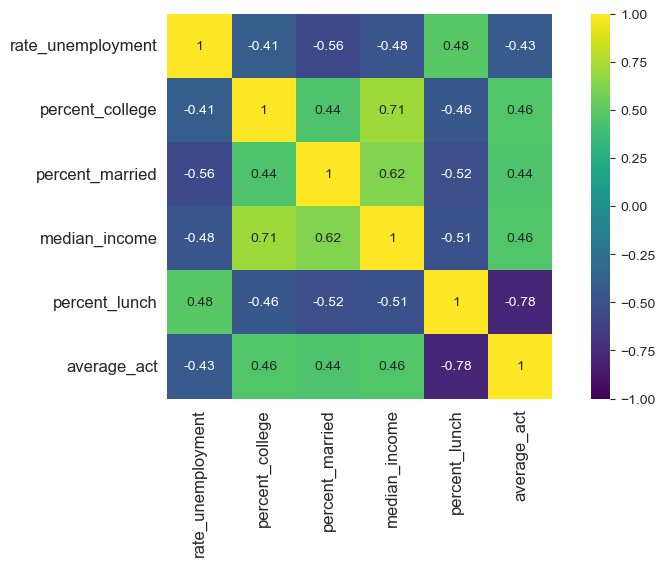

In [4]:
predictor_variables = ['rate_unemployment', 'percent_college', 'percent_married', 'median_income', 'percent_lunch', 'state', 'charter']

numerical_predictors = df[predictor_variables].select_dtypes(include='number').columns.to_list()

corr_matrix = df[numerical_predictors + ["average_act"]].corr()

plt.figure(figsize=(10, 5))

sns.heatmap(
    corr_matrix, vmax=1, vmin=-1, square=True, annot=True, cmap="viridis"
)

plt.tick_params(labelsize=12)

plt.show()

We can see that the strongest correlations with ACT/SAT scores is percent of free lunch, similar like we identified during data preparation. Other factors show moderate correlations, indicating multiple influences on student performance.

Next we will show pair plots to explore relationships between the variables. We will differentiate regression lines by charter school status to see if there are differences in trends.

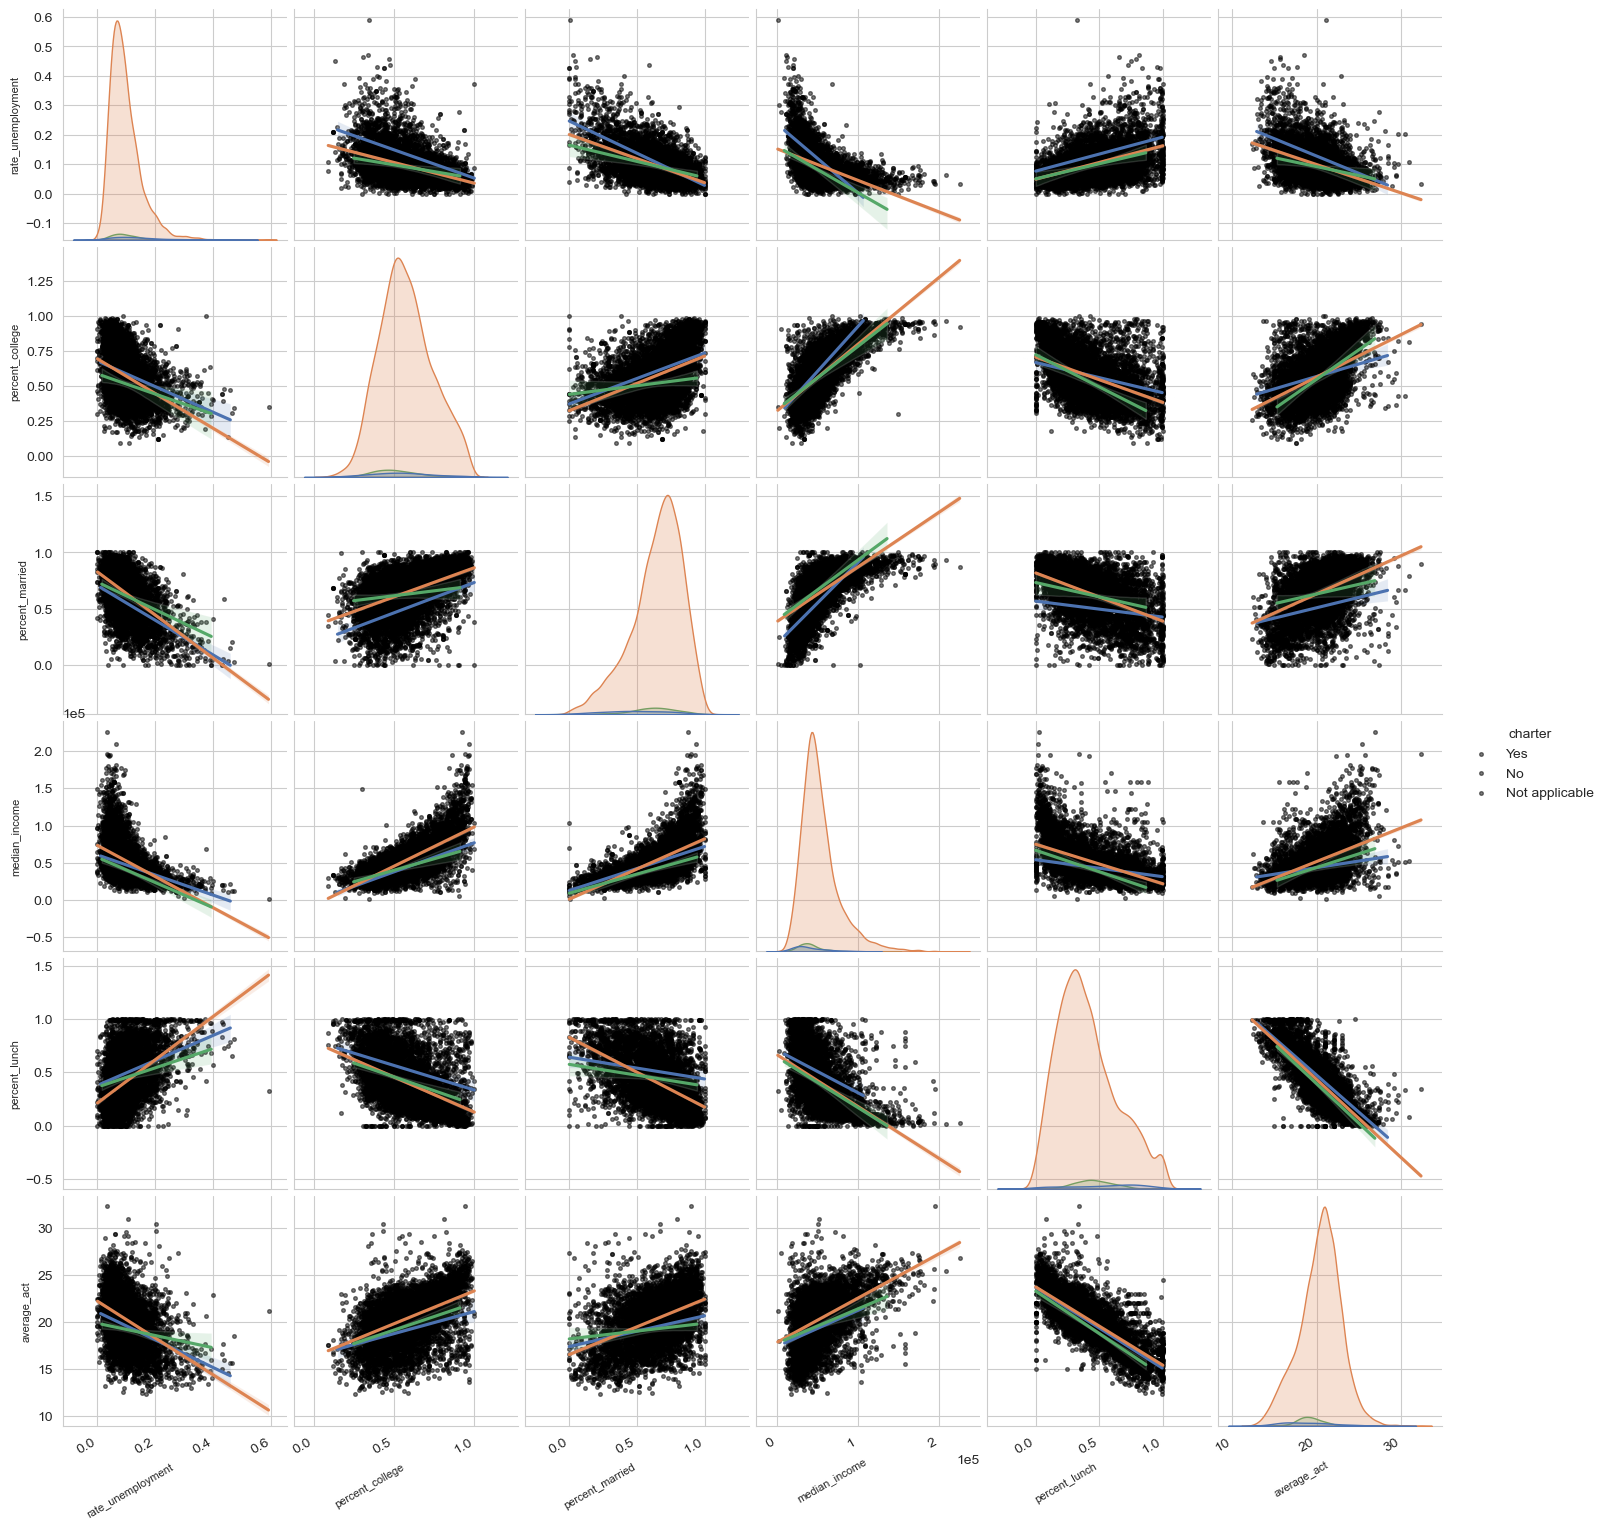

In [5]:
fig = sns.pairplot(
    data=df,
    vars=numerical_predictors + ['average_act'],
    hue='charter',
    kind="reg",
    plot_kws={"scatter_kws": {"alpha": 0.5, "color": "k", "s": 7},
    },
)

for ax in fig.axes.flat:
    if ax.get_xlabel() == 'median_income':
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))  # Apply scientific notation
    if ax.get_ylabel() == 'median_income':
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))  # Apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right')  # X-axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)  # Y-axis label size

    # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.show()

We can notice small differences in trends between charter and non-charter schools, but overall the relationships are similar. We can also see correlation between predictor variables, such as median income and percent of free lunch which means that not all predictors will be required in the model. Distributions plots show that some variables have skewed distributions, which may require transformation for modeling.

### Identify outliers

We can use the interquartile range to identify outliers. Outliers can have a significant impact on regression models, so we will need to consider how to handle them.

#### Numerical predictors minus median income boxplots

We will first look at rate of unemployment, percent of free lunch, percent of college, and percent of married predictors, and analyze median income separately due to its different scale.

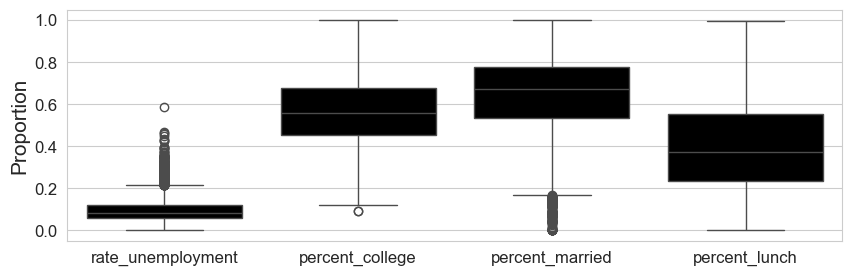

In [6]:
plt.figure(figsize=(10,3))

fractions = list(numerical_predictors)
fractions.remove('median_income')

sns.boxplot(data=df[fractions], color='k')

plt.ylabel('Proportion', fontsize=15)

plt.tick_params(labelsize=12)

plt.show()

From above plot we can notice most outliers in rate of unemployment and percent of married, with rate of unemplotyment having many outliers above the upper whisker and percent of married having many outliers below the lower whisker.

#### Median income boxplot

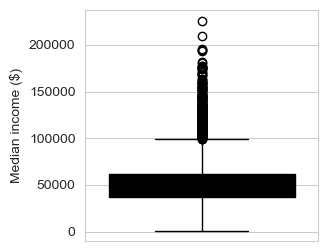

In [7]:
plt.figure(figsize=(3,3))

sns.boxplot(data=df, y='median_income', color='k')

plt.ylabel('Median income ($)')

plt.show()

Median income three quantile range is around 50,000 with outliers going up to nearly 300,000, idicating a large spread in income levels across the schools.

## Summary

1.  The numerical predictors are related to `average_act`. The relationships appear roughly linear.

2.  The numerical predictors are correlated with each other, suggesting that not all predictors will be necessary.

3.  Some variables have skewed distributions, suggesting that transformations of input variables might be useful.

4. There are outliers in `rate_unemployment`, `percent_college`, `percent_married` and `median_income`. None of these are obviously incorrect values; they likely reflect skewed distributions. We may consider applying something like a log transformation to these predictors as we explore different models.

5. The relationships are similar across charter and non-charter schools, but might be significantly different.

# Modeling

In this section, we will explore different modeling approaches to predict average ACT/SAT scores based on socioeconomic factors. We will start with a baseline linear regression model and then experiment with more complex models. We will evaluate model performance using appropriate metrics.

### Single input models

Fit and assess models predicting the average ACT score from each of the input variables. 

#### Median income

We will start with evaluating meadian income as a single predictor for average ACT/SAT scores.

##### Plot the regression line and the scatter plot

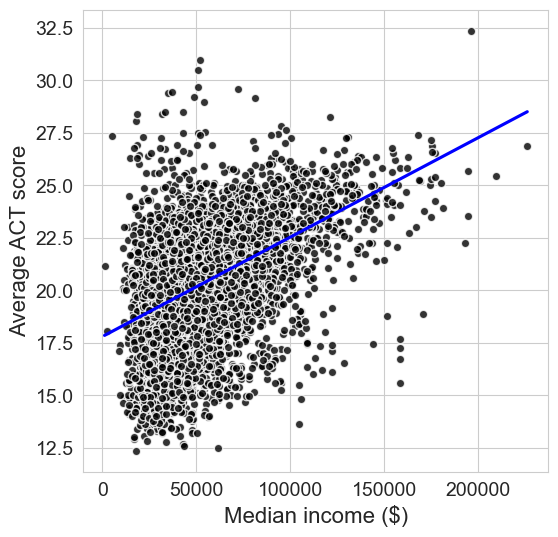

In [8]:
plt.figure(figsize=(6, 6))

sns.regplot(data=df,
            x='median_income',
            y='average_act',
            color='blue',
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

# Add axis labels
plt.xlabel('Median income ($)', fontsize=16)
plt.ylabel('Average ACT score', fontsize=16)

# Increase the fontsize of the tick labels
plt.tick_params(labelsize=14)

plt.show()

As we saw in the exploratory data analysis, there is visible relationship between median income and average ACT/SAT scores.

##### Fit the simple linear regression model

Here we will fit the simple linear regression model using median income as the predictor and print the model summary on how well median income predicts average ACT scores.

In [9]:
model_median_income = smf.ols(formula='average_act ~ median_income', data=df).fit()
print(model_median_income.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.211
Model:                            OLS   Adj. R-squared:                  0.211
Method:                 Least Squares   F-statistic:                     1934.
Date:                Sun, 26 Oct 2025   Prob (F-statistic):               0.00
Time:                        22:53:46   Log-Likelihood:                -16043.
No. Observations:                7227   AIC:                         3.209e+04
Df Residuals:                    7225   BIC:                         3.210e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        17.8026      0.063    284.794

In OLS report the most imporant to look at is P-value, which describes statistical significance of the predictor, and R-square, which describe percentage of variance in target variable which can be descibed by predictor. 
From above model summary we can see that median income is statistically significant predictor of average ACT/SAT scores (p-value < 0.05) and explains about 21.2% of the variance in average ACT/SAT scores (R-squared = 0.212).


##### Numerical assessment of fit accuracy

We can also evaluate the model performance using RMSE and MAE metrics, which provide insights into the average prediction error of the model.

Compute the RMSE

Root Mean Squared Error (RMSE) is a commonly used metric to evaluate the accuracy of regression models, which has higher weight on larger errors.

In [10]:
y_hat = model_median_income.predict()

In [11]:
np.sqrt(mean_squared_error(df['average_act'], y_hat)).round(3)

np.float64(2.228)

It means that on average, the model's predictions are off by about 2.3 ACT points. Considering that ACT scores range from 1-36, which is pretty good for a single predictor model.

Compute the mean absolute error

Mean Absolute Error (MAE) is another metric to evaluate regression model accuracy, which gives equal weight to all errors.

In [12]:
mean_absolute_error(df['average_act'], y_hat)

1.7129386980688601

Using MAE, we find that on average, the model's predictions differ from the actual ACT scores by about 1.7 points. 

##### Use a residual plot for graphical assessment of model fit

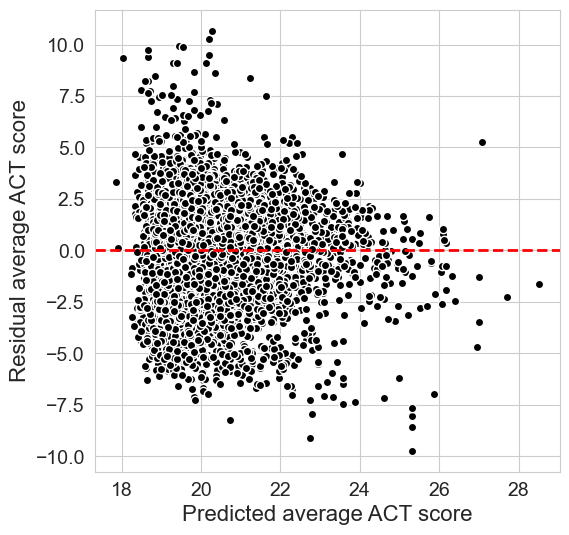

In [13]:
plt.figure(figsize=(6, 6))

plt.plot(y_hat, model_median_income.resid, 'ko', mec='w')
plt.axhline(0, color='r', linestyle='dashed', lw=2)

plt.xlabel('Predicted average ACT score', fontsize=16)
plt.ylabel('Residual average ACT score', fontsize=16)

plt.tick_params(labelsize=14)

plt.show()

##### Try a quadratic model. Plot the regression curves and the scatter plot

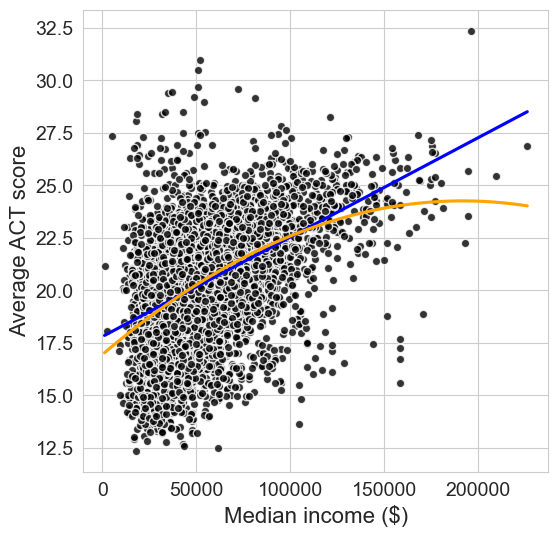

In [14]:
plt.figure(figsize=(6, 6))

sns.regplot(data=df,
            x='median_income',
            y='average_act',
            color='blue',
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

sns.regplot(data=df,
            x='median_income',
            y='average_act',
            order=2,
            color='orange',
            ci=False,
            scatter=False)

# Add axis labels
plt.xlabel('Median income ($)', fontsize=16)
plt.ylabel('Average ACT score', fontsize=16)

# Increase the fontsize of the tick labels
plt.tick_params(labelsize=14)

plt.show()

##### Fit a quadratic linear regression model

In [15]:
model_median_income2 = smf.ols(
    formula='average_act ~ median_income + I(median_income**2)',
    data=df).fit()

##### Display the fit summary

In [16]:
print(model_median_income2.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.219
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                     1013.
Date:                Sun, 26 Oct 2025   Prob (F-statistic):               0.00
Time:                        22:53:48   Log-Likelihood:                -16007.
No. Observations:                7227   AIC:                         3.202e+04
Df Residuals:                    7224   BIC:                         3.204e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                16.94

<pre>
























</pre>

##### Assess the model significance

In [17]:
model_median_income2.pvalues

Intercept                0.000000e+00
median_income            2.631899e-99
I(median_income ** 2)    1.395848e-17
dtype: float64

In [18]:
anova_lm(model_median_income, model_median_income2)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,7225.0,35865.012794,0.0,NaN,NaN,NaN
1,7224.0,35505.105960,1.0,359.906834,73.227974,1.395848e-17


<pre>
























</pre>

##### Assess the model accuracy

Compute the mean absolute error

In [19]:
mean_absolute_error(df['average_act'], model_median_income2.predict())

1.6972389257619853

<pre>
























</pre>

##### Compare the quadratic model accuracy to the first order model

In [20]:
mean_absolute_error(df['average_act'], model_median_income2.predict())

1.6972389257619853

In [21]:
mean_absolute_error(df['average_act'], model_median_income.predict())

1.7129386980688601

<pre>
























</pre>

#### Unemployment rate

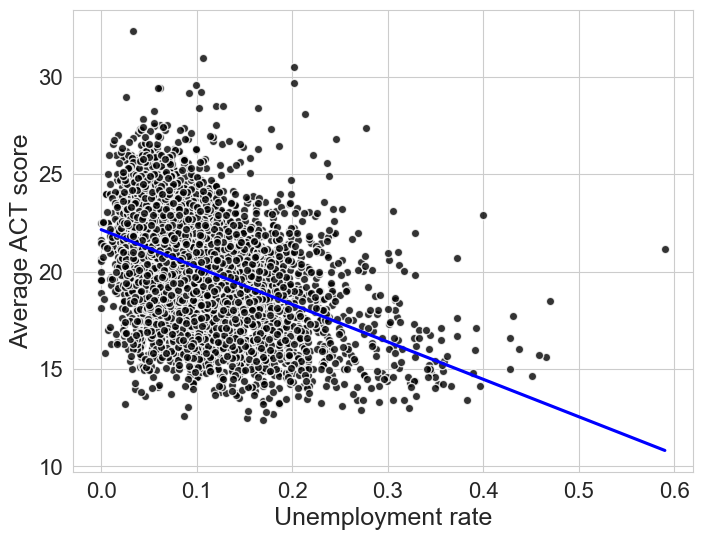

In [22]:
plt.figure(figsize=(8, 6))

sns.regplot(data=df,
            x='rate_unemployment',
            y='average_act',
            color='blue',
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1}
)

# Add axis labels
plt.xlabel('Unemployment rate', fontsize = 18)
plt.ylabel('Average ACT score', fontsize = 18)

# Increase the fontsize of the tick labels
plt.tick_params(labelsize = 16)

plt.show()

In [23]:
model_ru = smf.ols(formula='average_act ~ rate_unemployment', data=df).fit()

In [24]:
print(model_ru.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.188
Model:                            OLS   Adj. R-squared:                  0.188
Method:                 Least Squares   F-statistic:                     1669.
Date:                Sun, 26 Oct 2025   Prob (F-statistic):               0.00
Time:                        22:53:49   Log-Likelihood:                -16149.
No. Observations:                7227   AIC:                         3.230e+04
Df Residuals:                    7225   BIC:                         3.232e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            22.1512      0.05

The model is significant, but it is not great. The $R^2 = 0.19$, which is low.

Make a residual plot to assess the model.

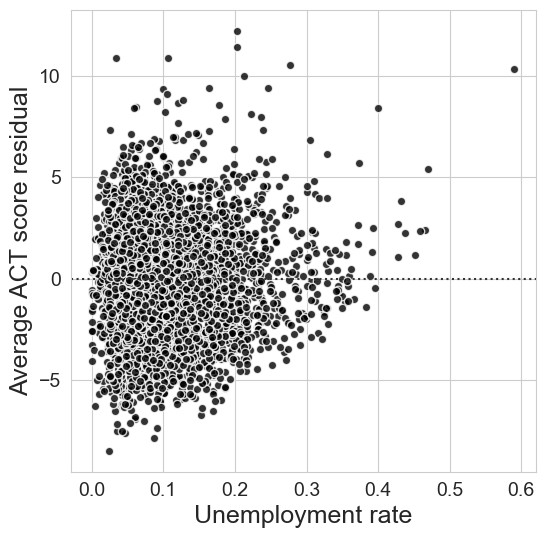

In [25]:
plt.figure(figsize=(6,6))

# residual plot
sns.residplot(data=df,
              x = 'rate_unemployment',
              y = 'average_act',
              scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

# Add axis labels
plt.xlabel('Unemployment rate', fontsize = 18)
plt.ylabel('Average ACT score residual', fontsize = 18)

# Increase the fontsize of the tick labels
plt.tick_params(labelsize=14)

plt.show()

Test whether a quadratic model is better.

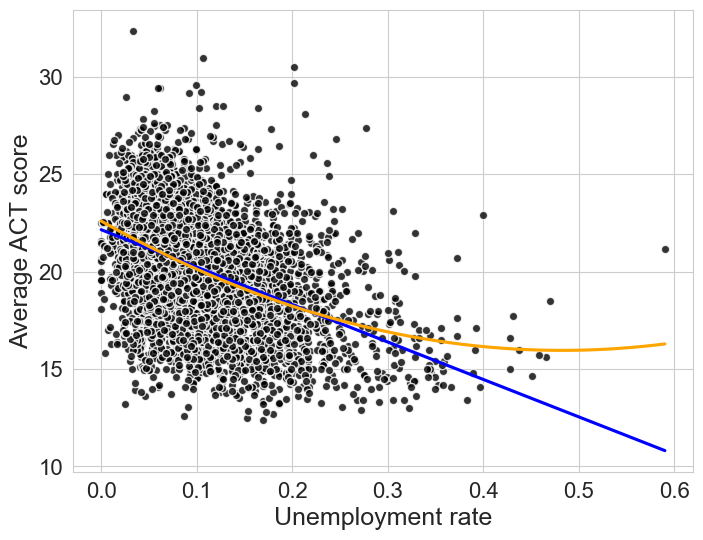

In [26]:
plt.figure(figsize=(8,6))

sns.regplot(x='rate_unemployment',
            y='average_act',
            color='blue',
            data=df,
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

sns.regplot(x='rate_unemployment',
            y='average_act',
            color='orange',
            order = 2,
            data=df,
            ci=False,
            scatter=False)

# Add axis labels
plt.xlabel('Unemployment rate', fontsize = 18)
plt.ylabel('Average ACT score', fontsize = 18)


# Increase the fontsize of the tick labels
plt.tick_params(labelsize = 16)

plt.show()

In [27]:
model_ru2 = smf.ols(formula='average_act ~ rate_unemployment + I(rate_unemployment**2)', data=df).fit()

In [28]:
df.head()

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,year,state,zip_code,school_type,school_level,charter
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,2016-2017,DE,19804,Regular School,High,Yes
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412,2016-2017,DE,19709,Regular School,High,No
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816,2016-2017,DE,19709,Regular School,High,No
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960,2016-2017,DE,19958,Regular School,High,No
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641,2016-2017,DE,19934,Regular School,High,No


In [29]:
print(model_ru2.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     865.0
Date:                Sun, 26 Oct 2025   Prob (F-statistic):               0.00
Time:                        22:53:51   Log-Likelihood:                -16125.
No. Observations:                7227   AIC:                         3.226e+04
Df Residuals:                    7224   BIC:                         3.228e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

A quadratic model is significant, but it does not improve the fit by much.

In [30]:
anova_lm(model_ru, model_ru2)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,7225.0,36932.894308,0.0,NaN,NaN,NaN
1,7224.0,36682.406013,1.0,250.488295,49.329574,2.360918e-12


**Build a single input model for one of the other predictors**

#### Percent of adults with a college degree

In [31]:
plt.figure(figsize=(8,6))

sns.regplot(data=df,
            x='percent_college',
            y='average_act',
            color='blue',
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

# Add axis labels
plt.xlabel('Percent college', fontsize = 18)
plt.ylabel('Average ACT score', fontsize = 18)


# Increase the fontsize of the tick labels
plt.tick_params(labelsize = 16);

In [32]:
model_pc = smf.ols(formula='average_act ~ percent_college', data=df).fit()

In [33]:
print(model_pc.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.210
Model:                            OLS   Adj. R-squared:                  0.210
Method:                 Least Squares   F-statistic:                     1922.
Date:                Sun, 26 Oct 2025   Prob (F-statistic):               0.00
Time:                        22:53:52   Log-Likelihood:                -16048.
No. Observations:                7227   AIC:                         3.210e+04
Df Residuals:                    7225   BIC:                         3.211e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          16.3039      0.095    1

The model is significant, but it is not great. The $R^2 = 0.20$, which is low.

#### Percent of adults married

In [34]:
plt.figure(figsize=(8,6))


sns.regplot(data=df,
            x='percent_married',
            y='average_act',
            color='blue',
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

# Add axis labels
plt.xlabel('Percent married', fontsize = 18)
plt.ylabel('Average ACT score', fontsize = 18)


# Increase the fontsize of the tick labels
plt.tick_params(labelsize = 16);

In [35]:
model_pm = smf.ols(formula='average_act ~ percent_married', data=df).fit()

In [36]:
print(model_pm.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     1733.
Date:                Sun, 26 Oct 2025   Prob (F-statistic):               0.00
Time:                        22:53:53   Log-Likelihood:                -16124.
No. Observations:                7227   AIC:                         3.225e+04
Df Residuals:                    7225   BIC:                         3.227e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          16.6046      0.093    1

The model is significant, but it is not great. The $R^2 = 0.20$, which is low.

#### Percent of students with free or reduced price lunch

In [37]:
plt.figure(figsize=(8,6))

sns.regplot(data=df,
            x='percent_lunch',
            y='average_act',
            color='blue',
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

# Add axis labels
plt.xlabel('Percent free or reduced price lunch', fontsize = 18)
plt.ylabel('Average ACT score', fontsize = 18)


# Increase the fontsize of the tick labels
plt.tick_params(labelsize = 16);

In [38]:
model_pl = smf.ols(formula='average_act ~ percent_lunch', data=df).fit()

print(model_pl.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.614
Model:                            OLS   Adj. R-squared:                  0.614
Method:                 Least Squares   F-statistic:                 1.149e+04
Date:                Sun, 26 Oct 2025   Prob (F-statistic):               0.00
Time:                        22:53:54   Log-Likelihood:                -13461.
No. Observations:                7227   AIC:                         2.693e+04
Df Residuals:                    7225   BIC:                         2.694e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        23.7429      0.037    641.745

There is a strong negative linear relationship between the percent of students with free or reduced price lunch and the average ACT score ($R^2 = 0.61$).

<pre>
























</pre>

# Multiple linear regression

Fit the multiple linear regression model using all socioeconomic variables as predictors.

In [39]:
model = smf.ols(
    formula='average_act ~ rate_unemployment + percent_college + percent_married + median_income + percent_lunch',
    data=df).fit()

<pre>
























</pre>

##### Print the summary

In [40]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.628
Model:                            OLS   Adj. R-squared:                  0.628
Method:                 Least Squares   F-statistic:                     2438.
Date:                Sun, 26 Oct 2025   Prob (F-statistic):               0.00
Time:                        22:53:54   Log-Likelihood:                -13328.
No. Observations:                7227   AIC:                         2.667e+04
Df Residuals:                    7221   BIC:                         2.671e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            22.6972      0.13

<pre>
























</pre>

##### Use a residual plot for graphical assessment of model fit

In [41]:
y_hat = model.predict()

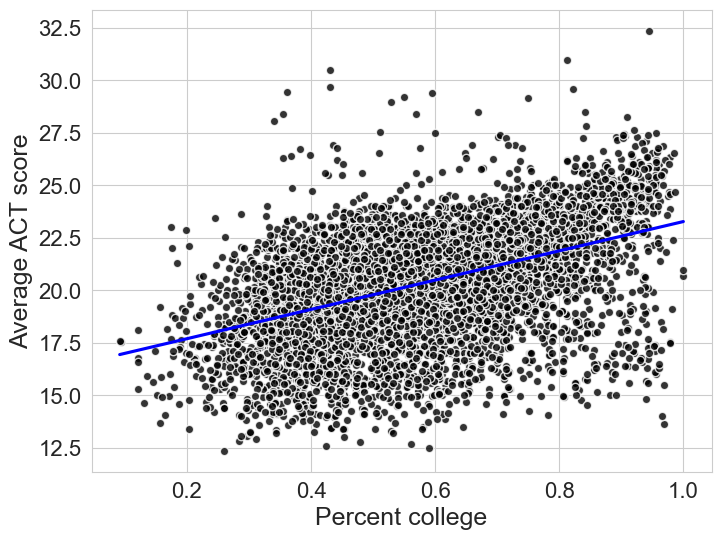

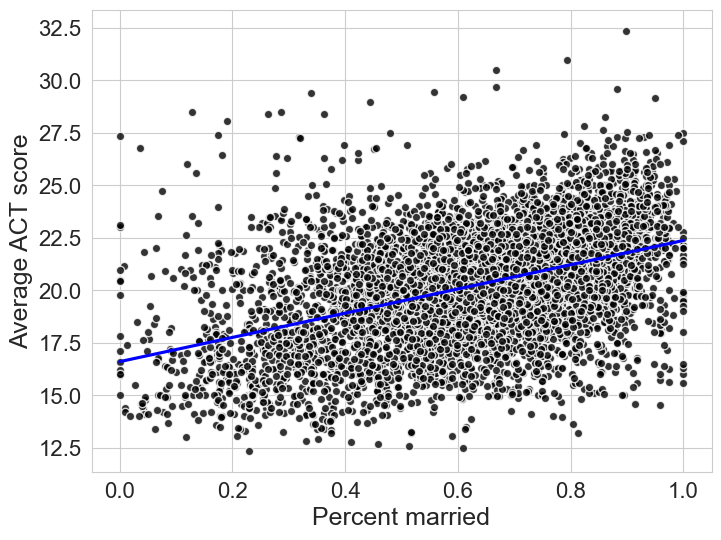

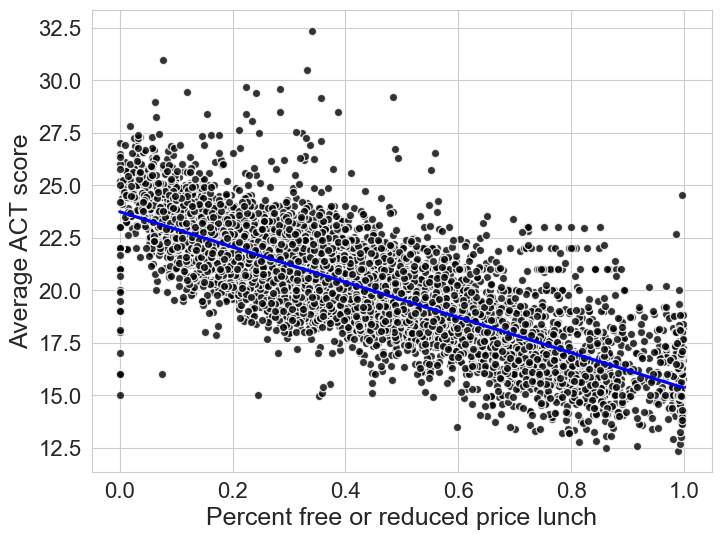

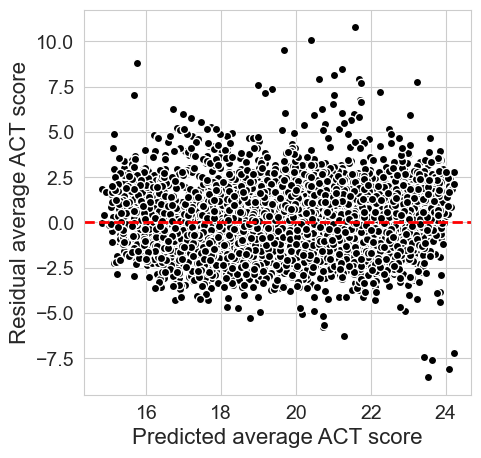

In [42]:
plt.figure(figsize=(5, 5))

plt.plot(y_hat, model.resid, 'ko', mec='w')
plt.axhline(0, color='r', linestyle='dashed', lw=2)

plt.xlabel('Predicted average ACT score', fontsize=16)
plt.ylabel('Residual average ACT score', fontsize=16)

plt.tick_params(labelsize=14)

plt.show()

<pre>
























</pre>

##### Compute the mean absolute error

In [43]:
mean_absolute_error(df['average_act'], model.predict())

1.1453304788844485

<pre>
























</pre>

## Summary

1. The multiple linear regression model with all socioeconomic predictors can predict ACT scores with an average error of roughly 1 point using these predictors.

2. The residual plot suggests that there will be limited improvement from adding transformations of these predictors.

3. Not all predictors have significant coefficients.

4. Adding predictors to the model may improve the performance.

<pre>
























</pre>

# Fit a reduced model with the significant predictors

In [44]:
model_reduced = smf.ols(
    formula='average_act ~ rate_unemployment + percent_college + percent_lunch',
    data=df).fit()

<pre>
























</pre>

##### Print the summary

In [45]:
print(model_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.628
Model:                            OLS   Adj. R-squared:                  0.628
Method:                 Least Squares   F-statistic:                     4063.
Date:                Sun, 26 Oct 2025   Prob (F-statistic):               0.00
Time:                        22:53:55   Log-Likelihood:                -13328.
No. Observations:                7227   AIC:                         2.666e+04
Df Residuals:                    7223   BIC:                         2.669e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            22.6400      0.10

<pre>
























</pre>

##### Use a residual plot for graphical assessment of model fit

In [46]:
y_hat = model_reduced.predict()

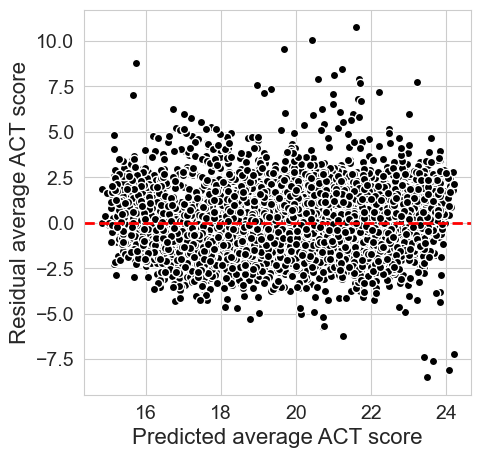

In [47]:
plt.figure(figsize=(5, 5))

plt.plot(y_hat, model_reduced.resid, 'ko', mec='w')
plt.axhline(0, color='r', linestyle='dashed', lw=2)

plt.xlabel('Predicted average ACT score', fontsize=16)
plt.ylabel('Residual average ACT score', fontsize=16)

plt.tick_params(labelsize=14)

plt.show()

<pre>
























</pre>

##### Compute the mean absolute error

In [48]:
mean_absolute_error(df['average_act'], model_reduced.predict())

1.1454832950346316

<pre>
























</pre>

##### Compare the accuracy between full and reduced models

In [49]:
mae_full = mean_absolute_error(df['average_act'], model.predict())
mae_reduced = mean_absolute_error(df['average_act'], model_reduced.predict())

r2_full = model.rsquared
r2_reduced = model_reduced.rsquared

pd.DataFrame({'Mean Absolute Error': [mae_full, mae_reduced],
              'R-squared': [r2_full, r2_reduced]},
              index=['full model', 'reduced model']).round(4)

,Mean Absolute Error,R-squared
full model,1.1453,0.6280
reduced model,1.1455,0.6279


<pre>
























</pre>

##### Use an ANOVA to test the significance of difference between models

In [50]:
anova_lm(model_reduced, model)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,7223.0,16916.619167,0.0,NaN,NaN,NaN
1,7221.0,16915.612457,2.0,1.006711,0.214874,0.806648


<pre>
























</pre>

## Summary

1. The model predicting the average ACT score from `rate_unemployment`, `percent_college` and, `percent_lunch` is not significantly different than the model with all five socioeconomic variables as predictors.

2. Adding predictors to the model may improve the performance.

3. We have not yet determined the relative importance of each predictor in the model.

<pre>
























</pre>

# Add charter school status as a predictor

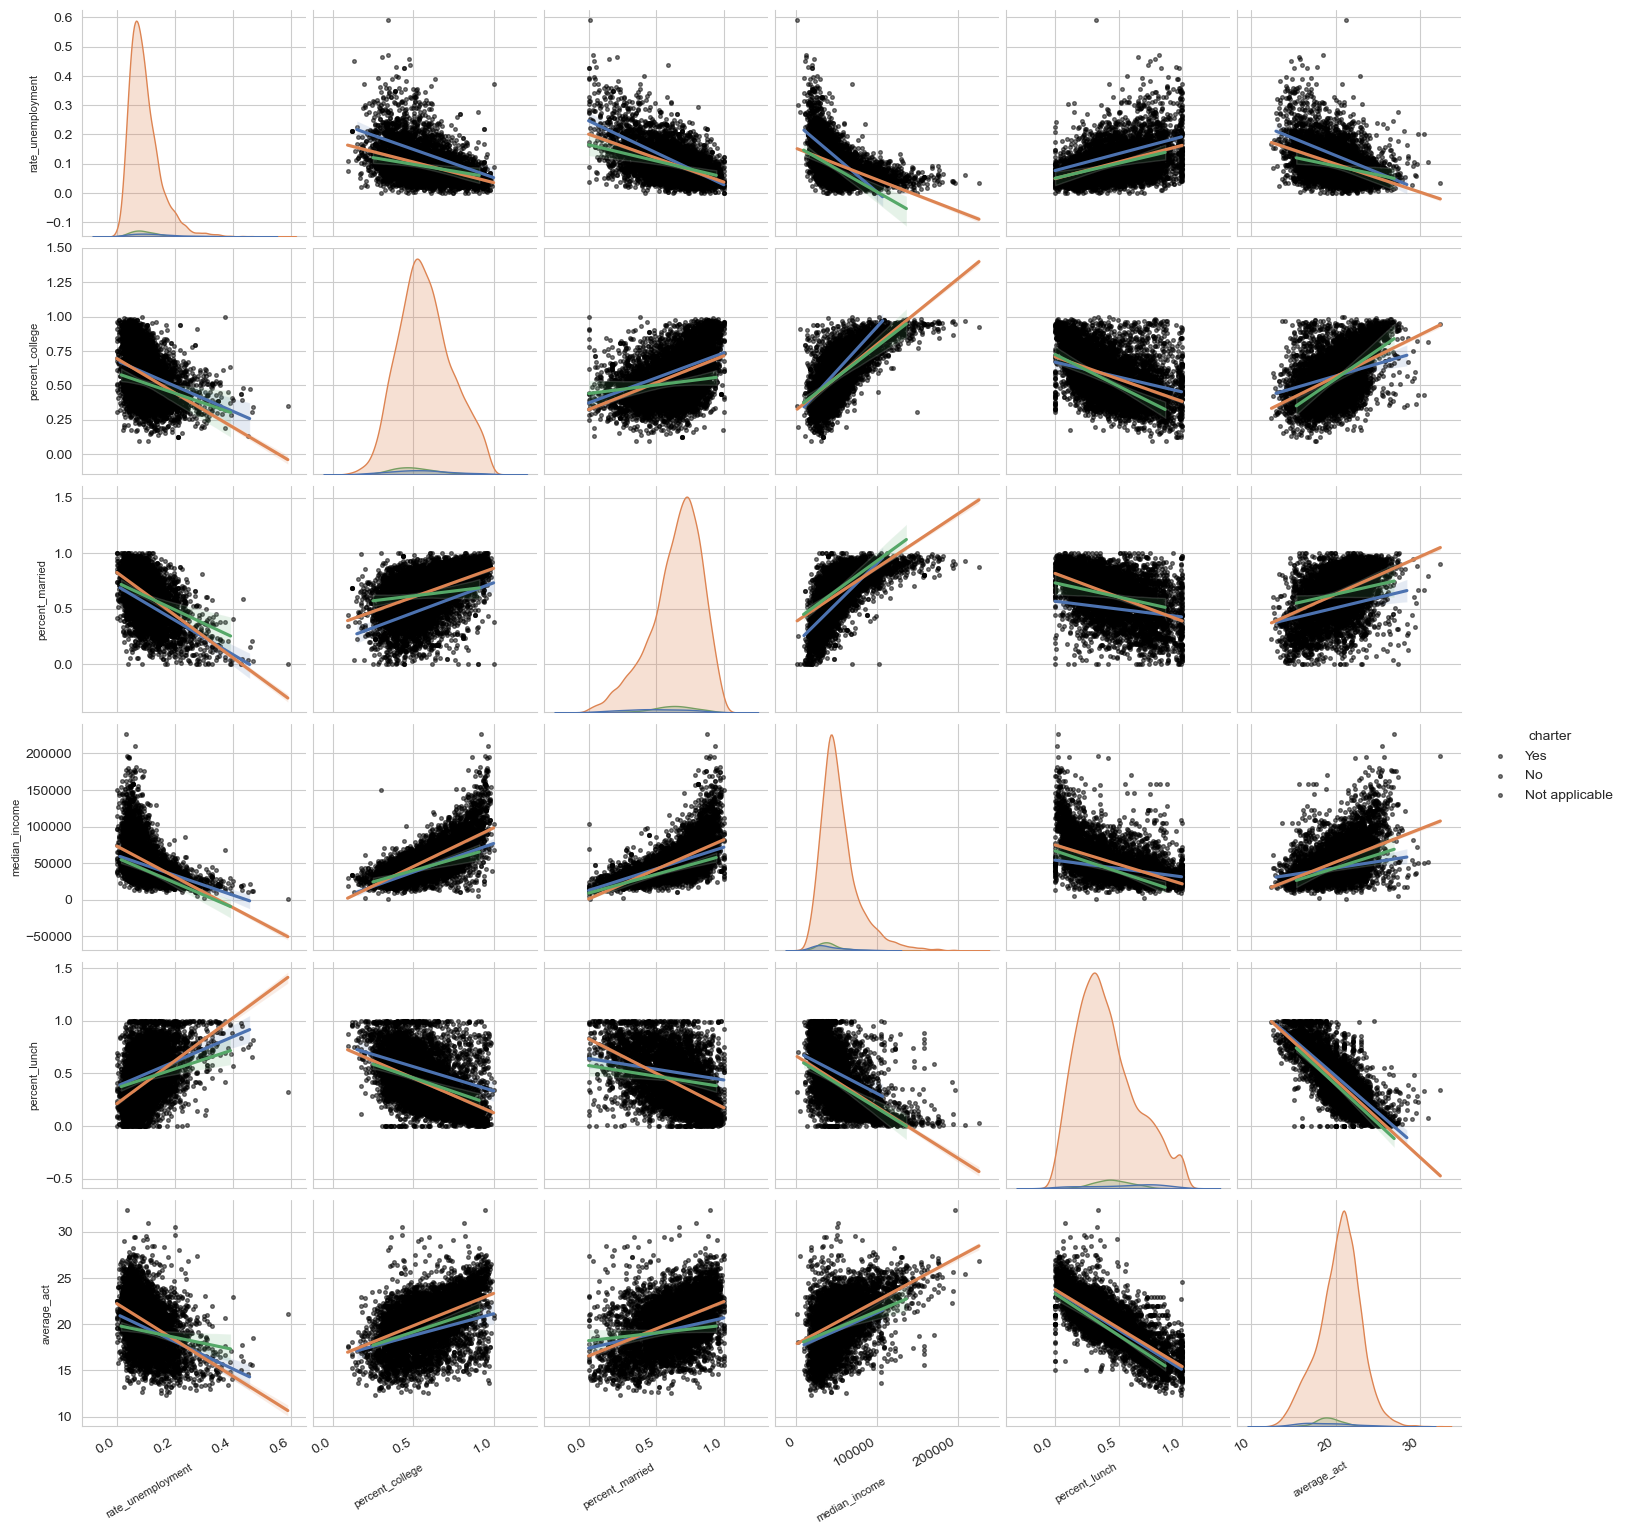

In [51]:
fig = sns.pairplot(
    data=df,
    vars=numerical_predictors + ['average_act'],
    hue='charter',
    kind="reg",
    plot_kws={"scatter_kws": {"alpha": 0.5, "color": "k", "s": 7},
    },
)

for ax in fig.axes.flat:
    if ax.get_xlabel() == 'CT Median Household Income':
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))  # Apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right')  # X-axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)  # Y-axis label size

    # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.show()

Create a model where the intercept can vary between schools based on charter school status

In [52]:
model_charter = smf.ols(
    formula='average_act ~ rate_unemployment + percent_college + percent_lunch + C(charter)',
    data=df).fit()

<pre>
























</pre>

##### Print the summary

In [53]:
print(model_charter.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.630
Model:                            OLS   Adj. R-squared:                  0.630
Method:                 Least Squares   F-statistic:                     2459.
Date:                Sun, 26 Oct 2025   Prob (F-statistic):               0.00
Time:                        22:54:28   Log-Likelihood:                -13308.
No. Observations:                7227   AIC:                         2.663e+04
Df Residuals:                    7221   BIC:                         2.667e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

<pre>
























</pre>

##### Use a residual plot for graphical assessment of model fit

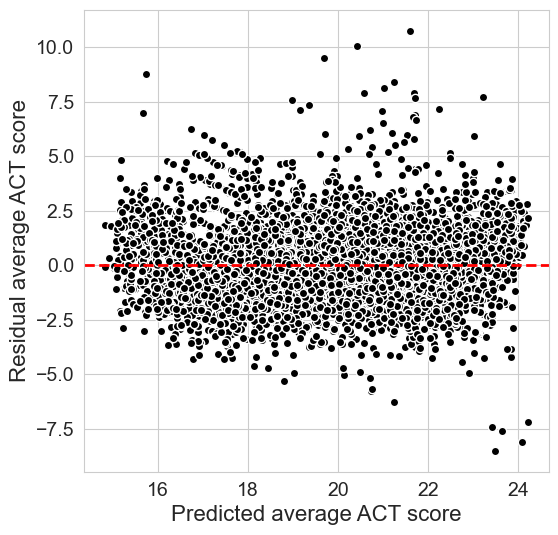

In [54]:
plt.figure(figsize=(6,6))

plt.plot(y_hat, model_charter.resid, 'ko', mec='w')
plt.axhline(0, color='r', linestyle='dashed', lw=2)

plt.xlabel('Predicted average ACT score', fontsize=16)
plt.ylabel('Residual average ACT score', fontsize=16)

plt.tick_params(labelsize=14)

plt.show()

<pre>
























</pre>

##### Compute the mean absolute error

In [55]:
mean_absolute_error(df['average_act'], model_charter.predict())

1.140411451570862

<pre>
























</pre>

##### Create a model where the intercept and slope can vary between schools based on charter school status

In [56]:
model_charter2 = smf.ols(formula='average_act ~ (rate_unemployment + percent_college + percent_lunch) * C(charter)', data=df).fit()

<pre>
























</pre>

##### Print the summary

In [57]:
print(model_charter2.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.631
Model:                            OLS   Adj. R-squared:                  0.630
Method:                 Least Squares   F-statistic:                     1120.
Date:                Sun, 26 Oct 2025   Prob (F-statistic):               0.00
Time:                        22:54:29   Log-Likelihood:                -13301.
No. Observations:                7227   AIC:                         2.663e+04
Df Residuals:                    7215   BIC:                         2.671e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

<pre>
























</pre>

##### Use a residual plot for graphical assessment of model fit

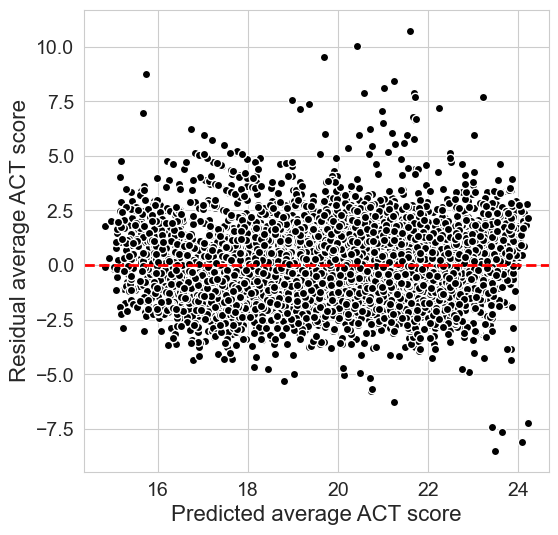

In [58]:
plt.figure(figsize=(6,6))

plt.plot(y_hat, model_charter2.resid, 'ko', mec='w')
plt.axhline(0, color='r', linestyle='dashed', lw=2)

plt.xlabel('Predicted average ACT score', fontsize=16)
plt.ylabel('Residual average ACT score', fontsize=16)

plt.tick_params(labelsize=14)

plt.show()

<pre>
























</pre>

##### Use an ANOVA to test the significance of difference between models

In [59]:
anova_lm(model_charter, model_charter2)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,7221.0,16821.669533,0.0,NaN,NaN,NaN
1,7215.0,16789.186717,6.0,32.482816,2.326532,0.030205


<pre>
























</pre>

##### Compute the mean absolute error

In [60]:
mean_absolute_error(df['average_act'], model_charter2.predict())

1.139733428612021

Compare to the intercept model

In [61]:
mean_absolute_error(df['average_act'], model_charter.predict())

1.140411451570862

<pre>
























</pre>

## Try a limited model using predictors with significant coefficients

##### Create a design matrix with all precitors

In [62]:
from patsy import dmatrices

In [63]:
y, X_design = dmatrices('average_act ~ (rate_unemployment + percent_college + percent_lunch) * C(charter)',
                        data=df,
                        return_type='dataframe'
                        )

In [64]:
X_design.head()

,Intercept,C(charter)[T.Not applicable],C(charter)[T.Yes],rate_unemployment,rate_unemployment:C(charter)[T.Not applicable],rate_unemployment:C(charter)[T.Yes],percent_college,percent_college:C(charter)[T.Not applicable],percent_college:C(charter)[T.Yes],percent_lunch,percent_lunch:C(charter)[T.Not applicable],percent_lunch:C(charter)[T.Yes]
0,1.0,0.0,1.0,0.117962,0.0,0.117962,0.445283,0.0,0.445283,0.066901,0.0,0.066901
1,1.0,0.0,0.0,0.063984,0.0,0.000000,0.662765,0.0,0.000000,0.112412,0.0,0.000000
2,1.0,0.0,0.0,0.056460,0.0,0.000000,0.701864,0.0,0.000000,0.096816,0.0,0.000000
3,1.0,0.0,0.0,0.044739,0.0,0.000000,0.692062,0.0,0.000000,0.296960,0.0,0.000000
4,1.0,0.0,0.0,0.077014,0.0,0.000000,0.640060,0.0,0.000000,0.262641,0.0,0.000000


<pre>
























</pre>

##### Keep only significant predictors from the full model

In [65]:
X = X_design.loc[:, model_charter2.pvalues<0.05]

print(X.columns)

Index(['Intercept', 'C(charter)[T.Yes]', 'rate_unemployment',
       'rate_unemployment:C(charter)[T.Yes]', 'percent_college',
       'percent_college:C(charter)[T.Yes]', 'percent_lunch'],
      dtype='object')


<pre>
























</pre>

##### Fit the model

In [66]:
model_charter3 = sm.OLS(y, X).fit()

<pre>
























</pre>

##### Print the summary

In [67]:
print(model_charter3.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.628
Model:                            OLS   Adj. R-squared:                  0.628
Method:                 Least Squares   F-statistic:                     2036.
Date:                Sun, 26 Oct 2025   Prob (F-statistic):               0.00
Time:                        22:54:29   Log-Likelihood:                -13322.
No. Observations:                7227   AIC:                         2.666e+04
Df Residuals:                    7220   BIC:                         2.671e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

<pre>
























</pre>

##### Compute the mean absolute error

In [68]:
mean_absolute_error(df['average_act'], model_charter3.predict())

1.1451732954718998

In [69]:
mean_absolute_error(df['average_act'], model_charter2.predict())

1.139733428612021

In [70]:
mean_absolute_error(df['average_act'], model_charter.predict())

1.140411451570862

<pre>
























</pre>

## Summary

1. Whether a school is a charter school or not can have a statistically significant, but practically small impact on the model.

<pre>
























</pre>

While a scaling transformation is not required for multiple linear regression models, scaling helps us to interpret the relative importance of each predictor based on the magnitude of the estimated coefficients.

# Scaling

##### Scale the predictor variables in the reduced model to have mean 0 and standard deviation 1 and add them to the data frame

In [71]:
predictor_variables = ['rate_unemployment', 'percent_college', 'percent_lunch']

In [72]:
scaled_columns = [var + '_normalized' for var in predictor_variables]

print(scaled_columns)

['rate_unemployment_normalized', 'percent_college_normalized', 'percent_lunch_normalized']


In [73]:
scaler = StandardScaler().fit(df[predictor_variables])

In [74]:
df[scaled_columns] = scaler.transform(df[predictor_variables])

<pre>
























</pre>

##### Check the mean and standard deviation of the transformed data.

In [75]:
df[scaled_columns].agg(['mean', 'std']).round(3)

,rate_unemployment_normalized,percent_college_normalized,percent_lunch_normalized
mean,0.0,-0.0,-0.0
std,1.0,1.0,1.0


<pre>
























</pre>

##### Fit the multiple linear regression model with the normalized predictors

In [76]:
model_normalized = smf.ols(
    formula='average_act ~ rate_unemployment_normalized + percent_college_normalized + percent_lunch_normalized',
    data=df).fit()

<pre>
























</pre>

##### Print the summary

In [77]:
print(model_normalized.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.628
Model:                            OLS   Adj. R-squared:                  0.628
Method:                 Least Squares   F-statistic:                     4063.
Date:                Sun, 26 Oct 2025   Prob (F-statistic):               0.00
Time:                        22:54:29   Log-Likelihood:                -13328.
No. Observations:                7227   AIC:                         2.666e+04
Df Residuals:                    7223   BIC:                         2.669e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

<pre>
























</pre>

##### Compare the accuracy between the original and normalized models

In [78]:
mae_normalized = mean_absolute_error(df['average_act'], model_normalized.predict())
mae_reduced = mean_absolute_error(df['average_act'], model_reduced.predict())

r2_normalized = model_normalized.rsquared
r2_reduced = model_reduced.rsquared

pd.DataFrame({'Mean Absolute Error': [mae_normalized, mae_reduced],
              'R-squared': [r2_normalized, r2_reduced]},
              index=['normalized model', 'reduced model']).round(4)

,Mean Absolute Error,R-squared
normalized model,1.1455,0.6279
reduced model,1.1455,0.6279


<pre>
























</pre>

## Summary

1. The percent of students at a school receiving free or reduced price lunch was the strongest predictor in this analysis.

<pre>
























</pre>

# Conclusion

The analysis shows that college entrance test scores (ACT and SAT) are related to socioeconomic variables.

In particular, using only the percent of students at a school receiving free or reduced price lunch, we can predict ACT scores to within a single point, on average.

The percent of students at a school receiving free or reduced price lunch was the strongest predictor in this analysis. It was also the only variable measured for students at the school, rather than for the neighborhood. It is an open question how important the other predictors would be if they were measured for the students at the school, rather than for the neighborhood.

